# 强化学习实验 - Monte Carlo Control with Visualization
这是对`exper.ipynb`的扩展版本，添加了多个可视化组件来更好地理解学习过程和结果。

In [ ]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from lib.envs.halften import HalftenEnv

env = HalftenEnv()

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

## Monte Carlo Control Implementation

我们使用ε-greedy策略的首次访问Monte Carlo控制方法。

In [11]:
def make_epsilon_greedy_policy(Q, epsilon, nA):
    def policy_fn(observation):
        A = np.ones(nA, dtype=float) * epsilon / nA
        best_action = np.argmax(Q[observation])
        A[best_action] += (1.0 - epsilon)
        return A
    return policy_fn

def mc_control_epsilon_greedy(env, num_episodes, discount_factor=1.0, epsilon=0.1, log_interval=1000):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)
    
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    policy = make_epsilon_greedy_policy(Q, epsilon, env.action_space.n)
    
    episode_rewards = []
    avg_rewards = []
    episode_Q_changes = []
    
    for i_episode in range(1, num_episodes + 1):
        episode = []
        state, _ = env.reset()
        
        episode_reward = 0
        
        for t in range(100):  
            probs = policy(state)
            action = np.random.choice(np.arange(len(probs)), p=probs)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            episode.append((state, action, reward))
            episode_reward += reward
            
            if done:
                break
            
            state = next_state
        
        episode_rewards.append(episode_reward)
        
        sa_in_episode = set([(x[0], x[1]) for x in episode])
        
        total_Q_change = 0
        for state, action in sa_in_episode:
            sa_pair = (state, action)
            first_occurence_idx = next(
                i for i, x in enumerate(episode)
                if x[0] == state and x[1] == action)
            
            G = sum([x[2] * (discount_factor ** i)
                for i, x in enumerate(episode[first_occurence_idx:])])
            
            old_Q = Q[state][action]

            returns_sum[sa_pair] += G
            returns_count[sa_pair] += 1.0
            
            Q[state][action] = returns_sum[sa_pair] / returns_count[sa_pair]
            total_Q_change += abs(Q[state][action] - old_Q)
        
        episode_Q_changes.append(total_Q_change)
        
        if i_episode % log_interval == 0:
            recent_rewards = episode_rewards[-log_interval:]
            avg_reward = np.mean(recent_rewards)
            avg_rewards.append((i_episode, avg_reward))
            print(f"Episode {i_episode}/{num_episodes}, Average Reward (last {log_interval} episodes): {avg_reward:.4f}")
    
    return Q, policy, episode_rewards, avg_rewards, episode_Q_changes

## 训练模型

我们训练50,000个episode来学习最优策略。

In [12]:
num_episodes = 50000
log_interval = 1000

print(f"开始训练，共{num_episodes}个episode...")
Q, policy, episode_rewards, avg_rewards, episode_Q_changes = mc_control_epsilon_greedy(
    env, 
    num_episodes=num_episodes,
    epsilon=0.1,
    log_interval=log_interval
)

print(f"训练完成！访问了{len(Q)}个不同的状态。")

开始训练，共50000个episode...
Episode 1000/50000, Average Reward (last 1000 episodes): 0.3540
Episode 2000/50000, Average Reward (last 1000 episodes): 0.4360
Episode 3000/50000, Average Reward (last 1000 episodes): 0.5690
Episode 4000/50000, Average Reward (last 1000 episodes): 0.5510
Episode 5000/50000, Average Reward (last 1000 episodes): 0.4740
Episode 6000/50000, Average Reward (last 1000 episodes): 0.6250
Episode 7000/50000, Average Reward (last 1000 episodes): 0.6270
Episode 8000/50000, Average Reward (last 1000 episodes): 0.5010
Episode 9000/50000, Average Reward (last 1000 episodes): 0.6060
Episode 10000/50000, Average Reward (last 1000 episodes): 0.6530
Episode 11000/50000, Average Reward (last 1000 episodes): 0.6110
Episode 12000/50000, Average Reward (last 1000 episodes): 0.5980
Episode 13000/50000, Average Reward (last 1000 episodes): 0.6390
Episode 14000/50000, Average Reward (last 1000 episodes): 0.6930
Episode 15000/50000, Average Reward (last 1000 episodes): 0.5600
Episode 160

## 可视化1: 学习曲线

显示平均奖励随训练步数的变化。

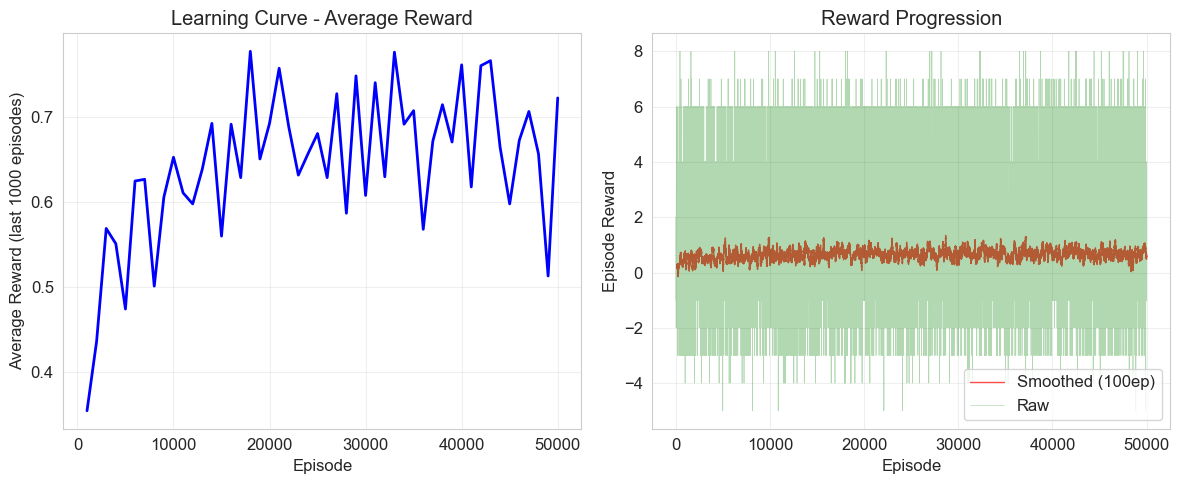

In [13]:
plt.figure(figsize=(12, 5))

# 创建子图1: 平均奖励
plt.subplot(1, 2, 1)
episodes, avg_rewards_data = zip(*avg_rewards)
plt.plot(episodes, avg_rewards_data, 'b-', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Average Reward (last 1000 episodes)')
plt.title('Learning Curve - Average Reward')
plt.grid(True, alpha=0.3)

# 创建子图2: 原始奖励
plt.subplot(1, 2, 2)
window_size = 100
if len(episode_rewards) > window_size:
    smoothed_rewards = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size, len(episode_rewards) + 1), smoothed_rewards, 'r-', linewidth=1, alpha=0.7, label=f'Smoothed ({window_size}ep)')
plt.plot(episode_rewards, 'g-', alpha=0.3, linewidth=0.5, label='Raw')
plt.xlabel('Episode')
plt.ylabel('Episode Reward')
plt.title('Reward Progression')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 可视化2: Q值变化

显示Q值在训练过程中的变化，这反映了学习进度。

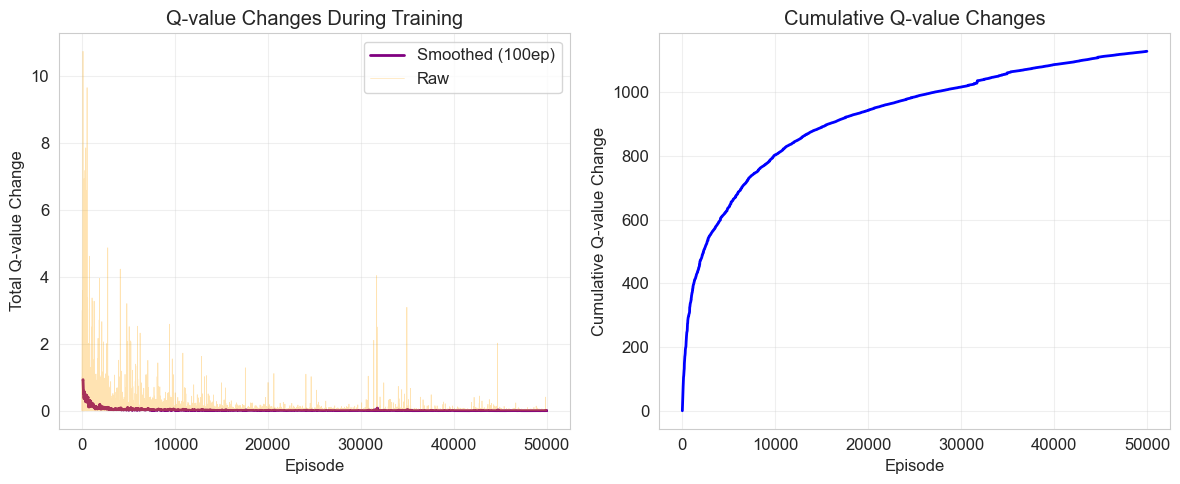

In [14]:
plt.figure(figsize=(12, 5))

# 子图1: Q值变化
plt.subplot(1, 2, 1)
window = 100
if len(episode_Q_changes) > window:
    smoothed_Q_changes = np.convolve(episode_Q_changes, np.ones(window)/window, mode='valid')
    plt.plot(range(window, len(episode_Q_changes) + 1), smoothed_Q_changes, 'purple', linewidth=2, label=f'Smoothed ({window}ep)')
plt.plot(episode_Q_changes, 'orange', alpha=0.3, linewidth=0.5, label='Raw')
plt.xlabel('Episode')
plt.ylabel('Total Q-value Change')
plt.title('Q-value Changes During Training')
plt.grid(True, alpha=0.3)
plt.legend()

# 子图2: 累计Q值变化
plt.subplot(1, 2, 2)
cumulative_Q_changes = np.cumsum(episode_Q_changes)
plt.plot(cumulative_Q_changes, 'b-', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Cumulative Q-value Change')
plt.title('Cumulative Q-value Changes')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 可视化3: Q值分布

分析学习到的Q值的分布。

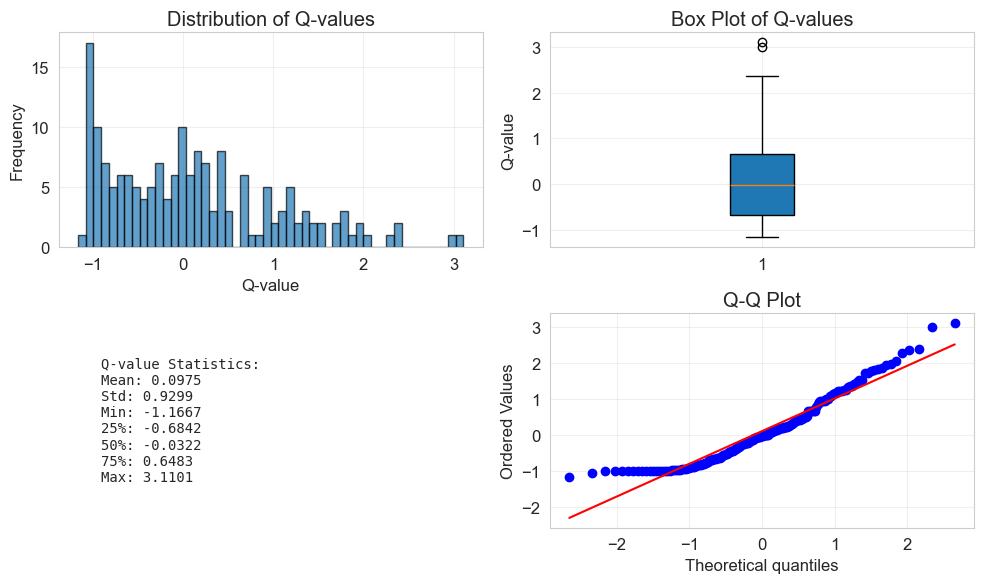

In [15]:
all_q_values = []
for state in Q:
    all_q_values.extend(Q[state])
all_q_values = np.array(all_q_values)

plt.figure(figsize=(10, 6))

# 直方图
plt.subplot(2, 2, 1)
plt.hist(all_q_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Q-value')
plt.ylabel('Frequency')
plt.title('Distribution of Q-values')
plt.grid(True, alpha=0.3)

# 箱线图
plt.subplot(2, 2, 2)
plt.boxplot(all_q_values, vert=True, patch_artist=True)
plt.ylabel('Q-value')
plt.title('Box Plot of Q-values')
plt.grid(True, alpha=0.3)

# Q值统计
plt.subplot(2, 2, 3)
stats_text = f"""
Q-value Statistics:
Mean: {np.mean(all_q_values):.4f}
Std: {np.std(all_q_values):.4f}
Min: {np.min(all_q_values):.4f}
25%: {np.percentile(all_q_values, 25):.4f}
50%: {np.percentile(all_q_values, 50):.4f}
75%: {np.percentile(all_q_values, 75):.4f}
Max: {np.max(all_q_values):.4f}
"""
plt.text(0.1, 0.5, stats_text, fontsize=10, transform=plt.gca().transAxes, 
         verticalalignment='center', fontfamily='monospace')
plt.axis('off')

# QQ图
plt.subplot(2, 2, 4)
from scipy import stats
stats.probplot(all_q_values, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 可视化4: 策略可视化

将学习到的策略可视化，显示在不同状态下推荐的动作。

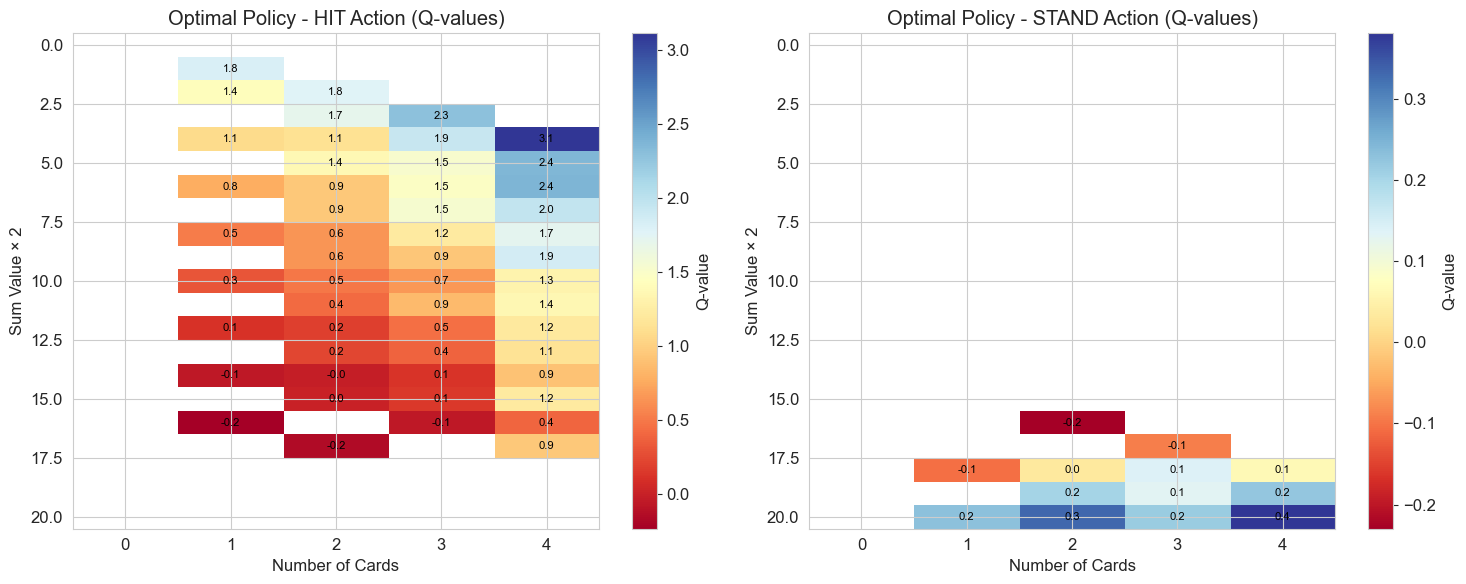

In [16]:
# 提取状态和最佳动作
states = list(Q.keys())
states.sort()

# 创建策略矩阵
max_sum = max(s[0] for s in states if isinstance(s[0], (int, float)))
max_cards = max(s[1] for s in states)
max_special = max(s[2] for s in states)

policy_matrix_hit = np.full((int(max_sum * 2) + 1, max_cards + 1), np.nan)  # 乘以2是因为有0.5
policy_matrix_stand = np.full((int(max_sum * 2) + 1, max_cards + 1), np.nan)

for state in states:
    sum_val, cards, special = state
    best_action = np.argmax(Q[state])
    
    idx_sum = int(sum_val * 2)  # 乘以2处理0.5
    idx_cards = cards
    
    if best_action == 1:  # Hit
        policy_matrix_hit[idx_sum, idx_cards] = Q[state][best_action]
        policy_matrix_stand[idx_sum, idx_cards] = np.nan
    else:  # Stand
        policy_matrix_stand[idx_sum, idx_cards] = Q[state][best_action]
        policy_matrix_hit[idx_sum, idx_cards] = np.nan

plt.figure(figsize=(15, 6))

# Hit动作热力图
plt.subplot(1, 2, 1)
mask_hit = np.isnan(policy_matrix_hit)
plt.imshow(policy_matrix_hit, cmap='RdYlBu', aspect='auto', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.xlabel('Number of Cards')
plt.ylabel('Sum Value × 2')
plt.title('Optimal Policy - HIT Action (Q-values)')
plt.xticks(range(max_cards + 1))
 
# 添加数值标签
for i in range(policy_matrix_hit.shape[0]):
    for j in range(policy_matrix_hit.shape[1]):
        if not np.isnan(policy_matrix_hit[i, j]):
            plt.text(j, i, f'{policy_matrix_hit[i, j]:.1f}', 
                     ha='center', va='center', fontsize=8, color='black')

# Stand动作热力图
plt.subplot(1, 2, 2)
mask_stand = np.isnan(policy_matrix_stand)
plt.imshow(policy_matrix_stand, cmap='RdYlBu', aspect='auto', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.xlabel('Number of Cards')
plt.ylabel('Sum Value × 2')
plt.title('Optimal Policy - STAND Action (Q-values)')
plt.xticks(range(max_cards + 1))

# 添加数值标签
for i in range(policy_matrix_stand.shape[0]):
    for j in range(policy_matrix_stand.shape[1]):
        if not np.isnan(policy_matrix_stand[i, j]):
            plt.text(j, i, f'{policy_matrix_stand[i, j]:.1f}', 
                     ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

## 可视化5: 动作偏好分析

分析在不同状态特征下，智能体更倾向于选择哪个动作。

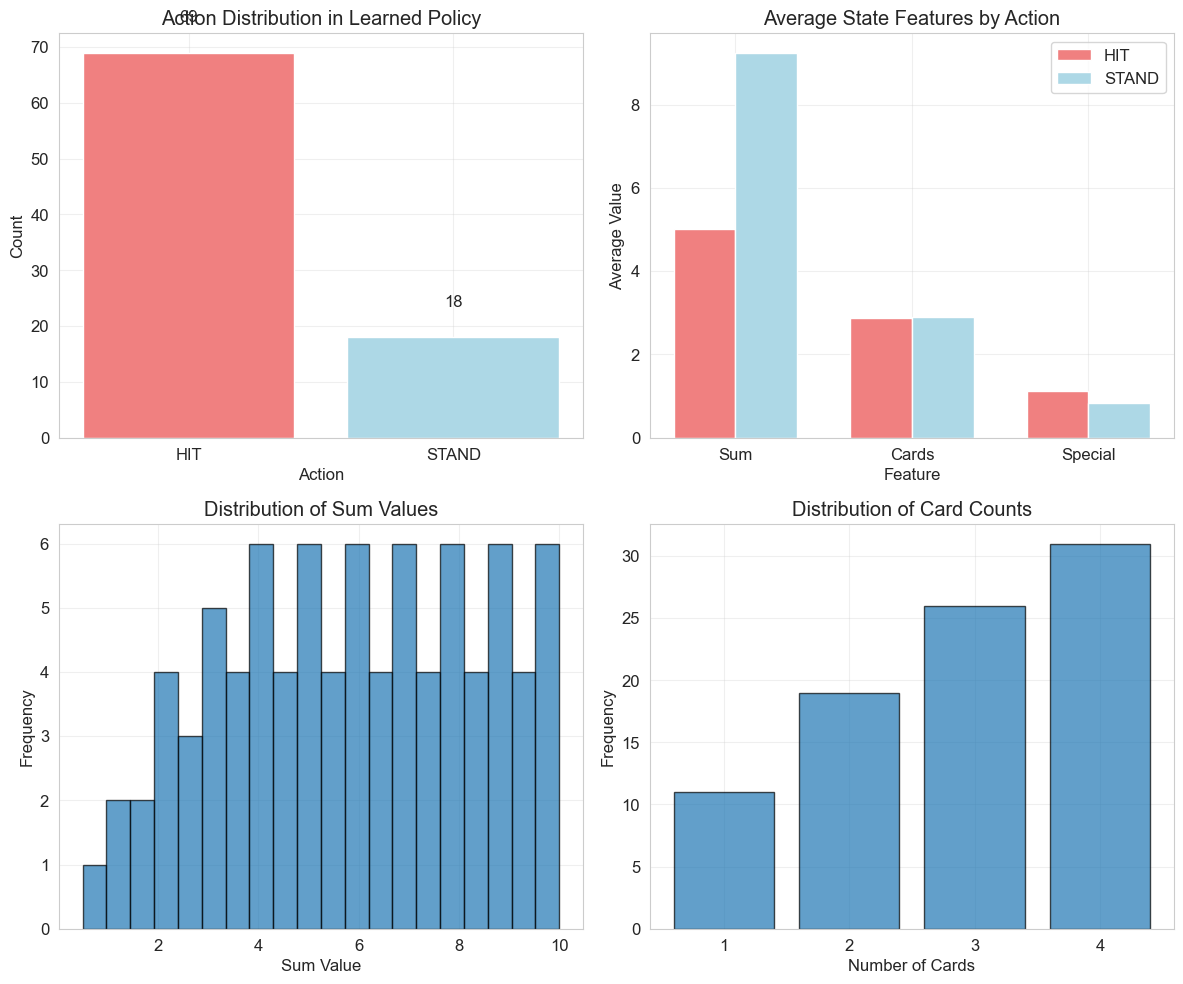

In [17]:
# 分析动作偏好
action_counts = {'HIT': 0, 'STAND': 0}
sum_by_action = {'HIT': 0, 'STAND': 0}
cards_by_action = {'HIT': 0, 'STAND': 0}
special_by_action = {'HIT': 0, 'STAND': 0}

for state in Q:
    sum_val, cards, special = state
    best_action = np.argmax(Q[state])
    
    if best_action == 1:  # Hit
        action_counts['HIT'] += 1
        sum_by_action['HIT'] += sum_val
        cards_by_action['HIT'] += cards
        special_by_action['HIT'] += special
    else:  # Stand
        action_counts['STAND'] += 1
        sum_by_action['STAND'] += sum_val
        cards_by_action['STAND'] += cards
        special_by_action['STAND'] += special

# 计算平均值
avg_sum_hit = sum_by_action['HIT'] / action_counts['HIT'] if action_counts['HIT'] > 0 else 0
avg_sum_stand = sum_by_action['STAND'] / action_counts['STAND'] if action_counts['STAND'] > 0 else 0
avg_cards_hit = cards_by_action['HIT'] / action_counts['HIT'] if action_counts['HIT'] > 0 else 0
avg_cards_stand = cards_by_action['STAND'] / action_counts['STAND'] if action_counts['STAND'] > 0 else 0
avg_special_hit = special_by_action['HIT'] / action_counts['HIT'] if action_counts['HIT'] > 0 else 0
avg_special_stand = special_by_action['STAND'] / action_counts['STAND'] if action_counts['STAND'] > 0 else 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 动作分布
ax1 = axes[0, 0]
actions = list(action_counts.keys())
counts = list(action_counts.values())
bars = ax1.bar(actions, counts, color=['lightcoral', 'lightblue'])
ax1.set_xlabel('Action')
ax1.set_ylabel('Count')
ax1.set_title('Action Distribution in Learned Policy')
ax1.grid(True, alpha=0.3)
# 添加数值标签
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count}', ha='center', va='bottom')

# 平均状态特征
ax2 = axes[0, 1]
features = ['Sum', 'Cards', 'Special']
hit_means = [avg_sum_hit, avg_cards_hit, avg_special_hit]
stand_means = [avg_sum_stand, avg_cards_stand, avg_special_stand]

x = np.arange(len(features))
width = 0.35

bars1 = ax2.bar(x - width/2, hit_means, width, label='HIT', color='lightcoral')
bars2 = ax2.bar(x + width/2, stand_means, width, label='STAND', color='lightblue')

ax2.set_xlabel('Feature')
ax2.set_ylabel('Average Value')
ax2.set_title('Average State Features by Action')
ax2.set_xticks(x)
ax2.set_xticklabels(features)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 状态特征分布
ax3 = axes[1, 0]
sum_values = [s[0] for s in states]
card_counts = [s[1] for s in states]
special_counts = [s[2] for s in states]

ax3.hist(sum_values, bins=20, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Sum Value')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Sum Values')
ax3.grid(True, alpha=0.3)

# 卡片数量分布
ax4 = axes[1, 1]
unique_cards, card_counts_vals = np.unique(card_counts, return_counts=True)
ax4.bar(unique_cards, card_counts_vals, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Number of Cards')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Card Counts')
ax4.set_xticks(unique_cards)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 可视化6: 最终评估

使用学习到的策略进行1000次测试episode，评估性能。

评估学习到的策略...


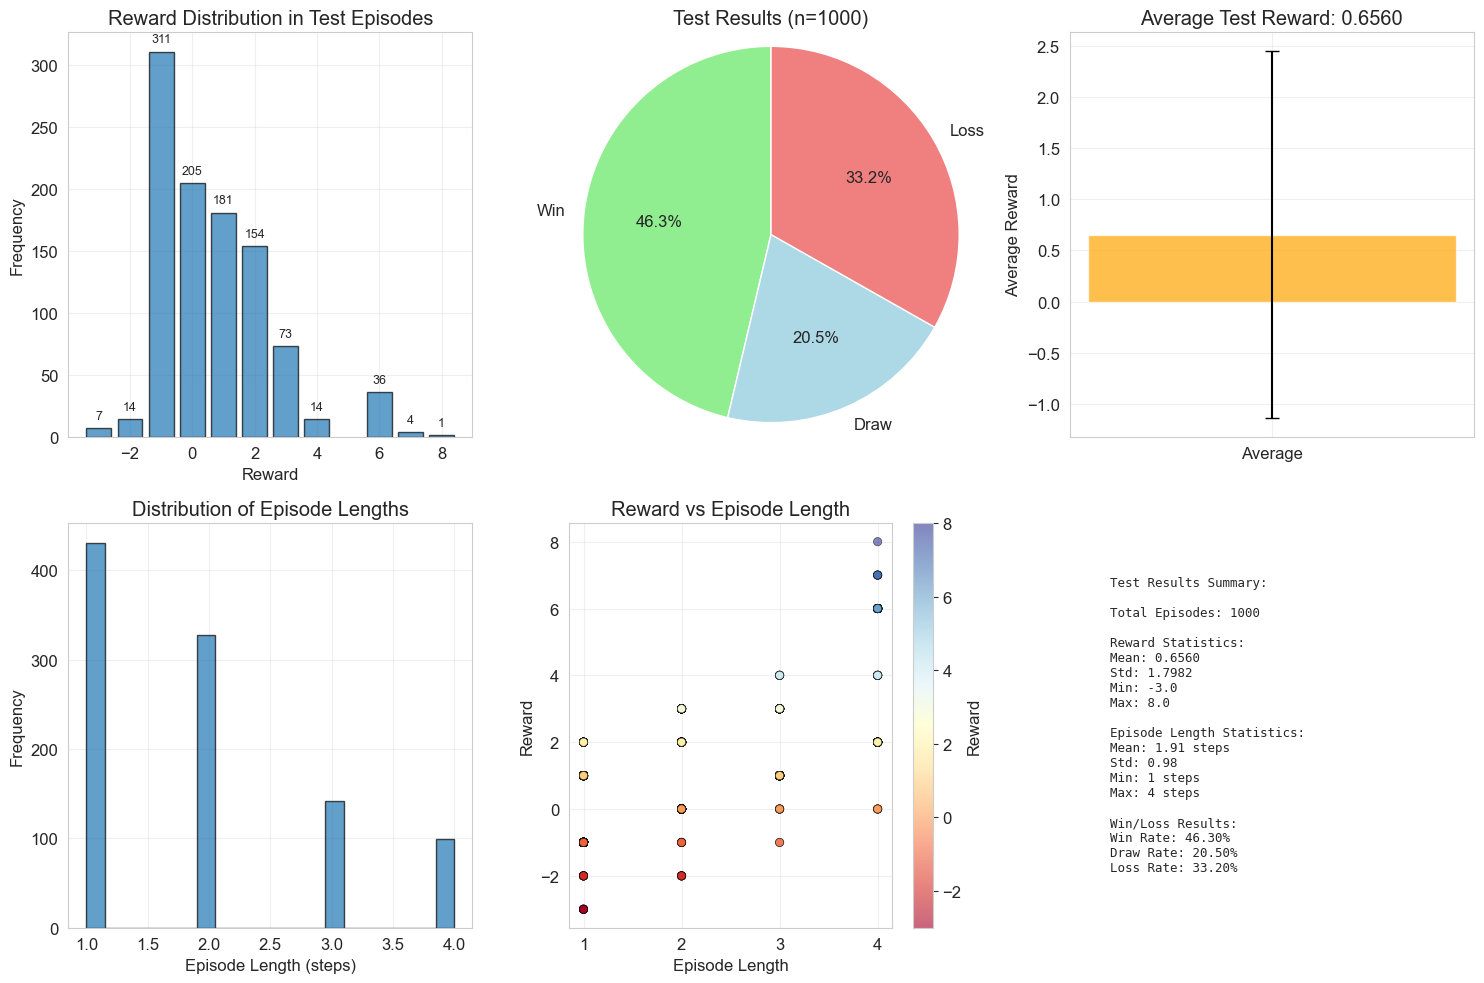

In [18]:
def evaluate_policy(env, policy, num_episodes=1000):
    total_rewards = []
    episode_lengths = []
    outcomes = []  # 1=赢, 0=平, -1=输
    
    for i in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        steps = 0
        
        for t in range(100):  
            probs = policy(state)
            action = np.random.choice(np.arange(len(probs)), p=probs)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            episode_reward += reward
            steps += 1
            
            if done:
                break
            
            state = next_state
        
        total_rewards.append(episode_reward)
        episode_lengths.append(steps)
        
        if episode_reward > 0:
            outcomes.append(1)  # 赢
        elif episode_reward == 0:
            outcomes.append(0)  # 平
        else:
            outcomes.append(-1)  # 输
    
    return total_rewards, episode_lengths, outcomes

# 评估策略
print("评估学习到的策略...")
test_rewards, test_lengths, test_outcomes = evaluate_policy(env, policy, num_episodes=1000)

# 计算统计数据
win_rate = sum(1 for o in test_outcomes if o == 1) / len(test_outcomes) * 100
draw_rate = sum(1 for o in test_outcomes if o == 0) / len(test_outcomes) * 100
loss_rate = sum(1 for o in test_outcomes if o == -1) / len(test_outcomes) * 100

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 奖励分布
ax1 = axes[0, 0]
unique_rewards, counts = np.unique(test_rewards, return_counts=True)
bars = ax1.bar(unique_rewards, counts, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Reward')
ax1.set_ylabel('Frequency')
ax1.set_title('Reward Distribution in Test Episodes')
ax1.grid(True, alpha=0.3)
# 添加数值标签
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count}', ha='center', va='bottom', fontsize=9)

# 输赢比例
ax2 = axes[0, 1]
labels = ['Win', 'Draw', 'Loss']
sizes = [win_rate, draw_rate, loss_rate]
colors = ['lightgreen', 'lightblue', 'lightcoral']
ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.axis('equal')
ax2.set_title(f'Test Results (n={len(test_outcomes)})')

# 平均奖励
ax3 = axes[0, 2]
ax3.bar(['Average'], [np.mean(test_rewards)], color='orange', alpha=0.7)
ax3.set_ylabel('Average Reward')
ax3.set_title(f'Average Test Reward: {np.mean(test_rewards):.4f}')
ax3.grid(True, alpha=0.3)
# 添加误差条
ax3.errorbar(['Average'], [np.mean(test_rewards)], yerr=[np.std(test_rewards)], 
             fmt='none', color='black', capsize=5)

# 回合长度分布
ax4 = axes[1, 0]
ax4.hist(test_lengths, bins=20, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Episode Length (steps)')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Episode Lengths')
ax4.grid(True, alpha=0.3)

# 奖励vs长度
ax5 = axes[1, 1]
scatter = ax5.scatter(test_lengths, test_rewards, c=test_rewards, 
                      cmap='RdYlBu', alpha=0.6, edgecolors='black', linewidth=0.5)
ax5.set_xlabel('Episode Length')
ax5.set_ylabel('Reward')
ax5.set_title('Reward vs Episode Length')
plt.colorbar(scatter, ax=ax5, label='Reward')
ax5.grid(True, alpha=0.3)

# 统计摘要
ax6 = axes[1, 2]
stats_text = f"""
Test Results Summary:

Total Episodes: {len(test_rewards)}

Reward Statistics:
Mean: {np.mean(test_rewards):.4f}
Std: {np.std(test_rewards):.4f}
Min: {np.min(test_rewards):.1f}
Max: {np.max(test_rewards):.1f}

Episode Length Statistics:
Mean: {np.mean(test_lengths):.2f} steps
Std: {np.std(test_lengths):.2f}
Min: {np.min(test_lengths)} steps
Max: {np.max(test_lengths)} steps

Win/Loss Results:
Win Rate: {win_rate:.2f}%
Draw Rate: {draw_rate:.2f}%
Loss Rate: {loss_rate:.2f}%
"""
ax6.text(0.1, 0.5, stats_text, fontsize=9, transform=ax6.transAxes, 
         verticalalignment='center', fontfamily='monospace')
ax6.axis('off')

plt.tight_layout()
plt.show()

## 结论

通过以上可视化，我们可以看到：

1. **学习进度**：平均奖励随训练逐渐提高，表明智能体在学习
2. **Q值收敛**：Q值变化逐渐减小，说明策略正在收敛
3. **策略模式**：热力图显示了在不同状态下的最优动作
4. **性能评估**：测试结果表明策略的有效性